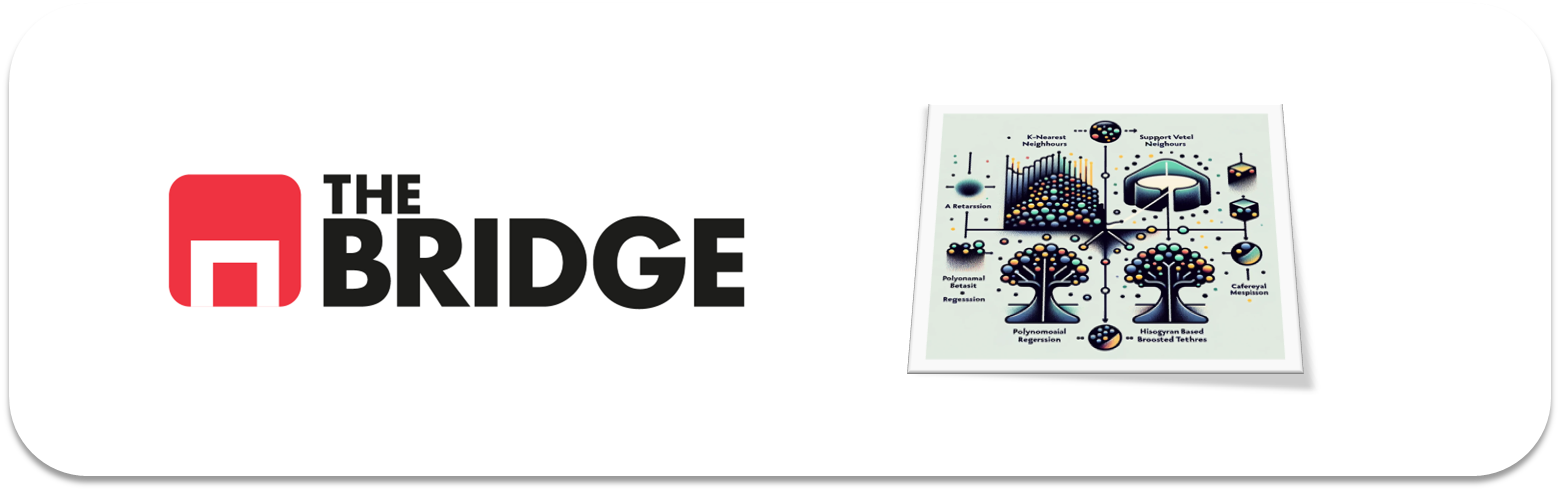

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')


pd.options.mode.copy_on_write = True



### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
df = pd.read_csv("data/credit_npo.csv")

# Primeras filas para ver cómo es el dataset
df.head()

# Información básica del dataset
df.info()

# Estadísticas básicas de las columnas numéricas
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12537.000000,12537.000000,12537.000000,12537.000000,12537.000000,11816.000000,12537.000000,12537.000000,12537.000000,12537.000000,12360.000000
mean,0.068916,0.330359,52.079445,0.409588,1.902253,6864.815420,8.482332,0.259312,0.999202,0.228364,0.822087
std,0.253321,0.368148,15.077498,4.055787,9.122216,11855.905437,5.165422,4.035658,1.134325,4.018873,1.136802
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030651,41.000000,0.000000,0.142268,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.163490,51.000000,0.000000,0.302025,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.582219,62.000000,0.000000,0.506725,8300.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


In [3]:
df.dtypes


SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Estamos ante un:

Problema de clasificación binaria supervisada

Target: SeriousDlqin2yrs (Si el cliente tuvo retraso >90 días en 2 años)

Queremos predecir si el cliente tendrá dificultades financieras (1) o no (0).

### #1.3
Pinta la distribución de frecuencias del target y coméntala

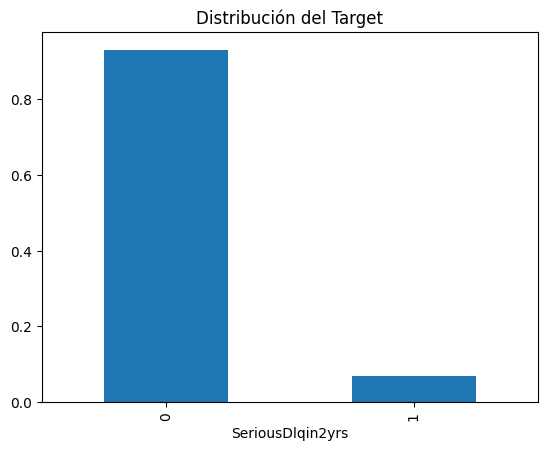

SeriousDlqin2yrs
0    0.931084
1    0.068916
Name: proportion, dtype: float64

In [4]:
df['SeriousDlqin2yrs'].value_counts(normalize=True).plot(kind='bar')
plt.title("Distribución del Target")
plt.show()

df['SeriousDlqin2yrs'].value_counts(normalize=True)


### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [5]:
# Limpieza

df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)


In [6]:
df['RevolvingUtilizationOfUnsecuredLines'].describe()


count    12537.000000
mean         0.330359
std          0.368148
min          0.000000
25%          0.030651
50%          0.163490
75%          0.582219
max          6.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

Tras el análisis exploratorio del dataset mediante info() y describe(), se observó que únicamente las variables MonthlyIncome y NumberOfDependents presentaban valores faltantes. Estas fueron imputadas mediante la mediana debido a la posible presencia de valores extremos. El resto de variables no presentaban inconsistencias, valores fuera de rango ni errores de codificación, por lo que no fue necesario realizar tratamientos adicionales.

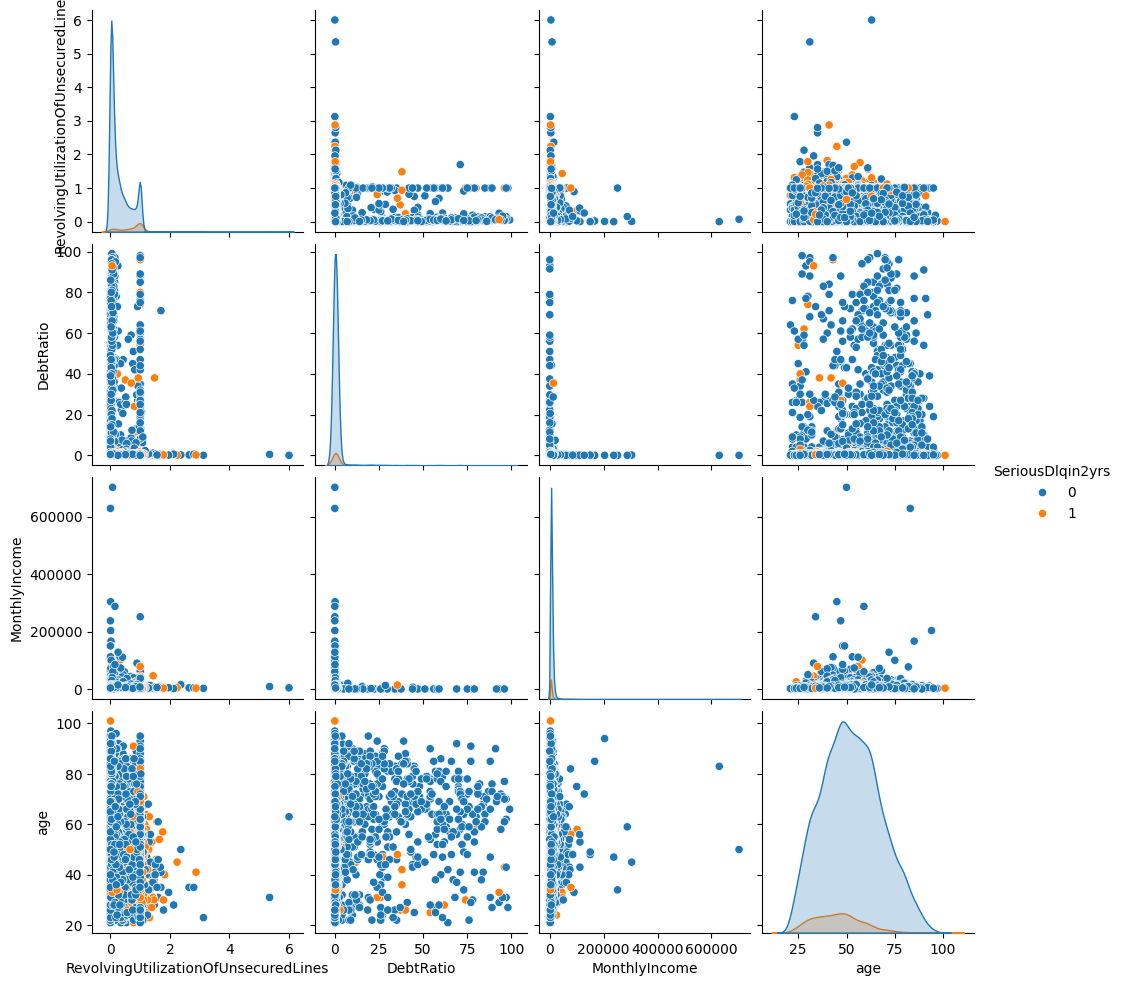

In [7]:
# Pairplot inicial

cols_continuas = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome',
    'age',
    'SeriousDlqin2yrs'
]

sns.pairplot(df[cols_continuas], hue='SeriousDlqin2yrs')
plt.show()


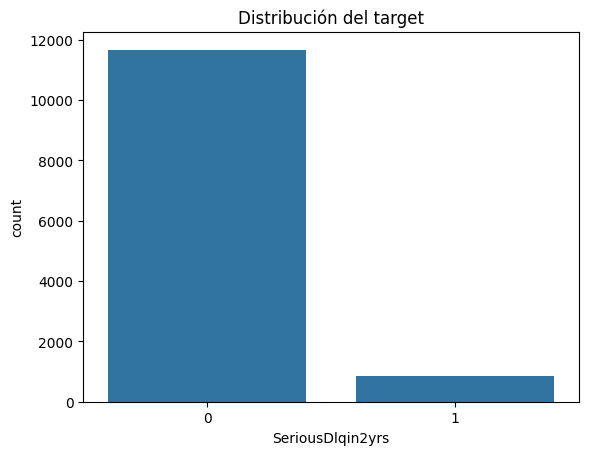

SeriousDlqin2yrs
0    0.931084
1    0.068916
Name: proportion, dtype: float64

In [8]:
# Estudio de la target 

sns.countplot(x='SeriousDlqin2yrs', data=df)
plt.title("Distribución del target")
plt.show()

df['SeriousDlqin2yrs'].value_counts(normalize=True)


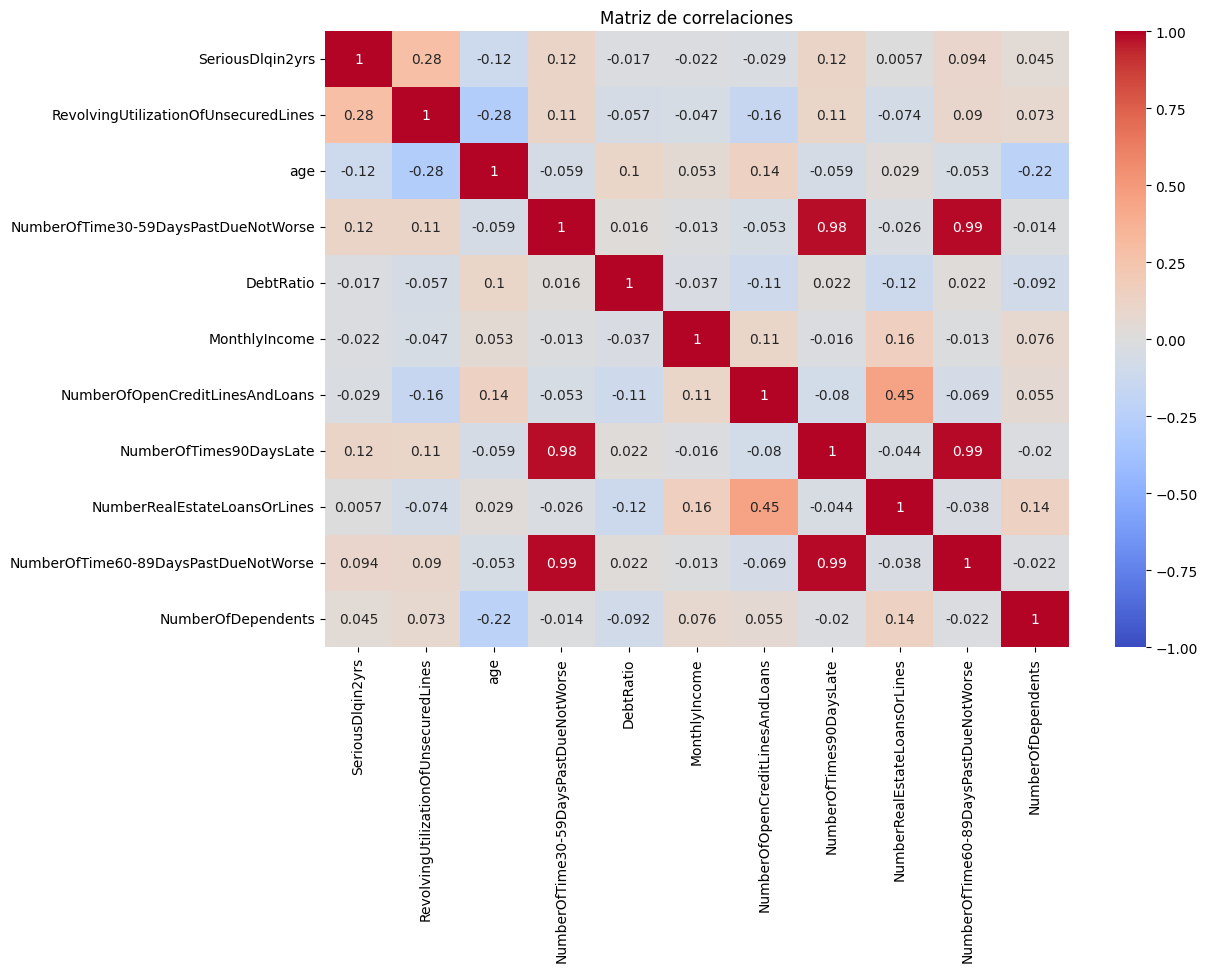

In [9]:
#Matriz de correlaciones 

plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    vmin=-1,
    vmax=1,
    cmap='coolwarm'
)
plt.title("Matriz de correlaciones")
plt.show()


array([[<Axes: title={'center': 'SeriousDlqin2yrs'}>,
        <Axes: title={'center': 'RevolvingUtilizationOfUnsecuredLines'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'NumberOfTime30-59DaysPastDueNotWorse'}>,
        <Axes: title={'center': 'DebtRatio'}>,
        <Axes: title={'center': 'MonthlyIncome'}>],
       [<Axes: title={'center': 'NumberOfOpenCreditLinesAndLoans'}>,
        <Axes: title={'center': 'NumberOfTimes90DaysLate'}>,
        <Axes: title={'center': 'NumberRealEstateLoansOrLines'}>],
       [<Axes: title={'center': 'NumberOfTime60-89DaysPastDueNotWorse'}>,
        <Axes: title={'center': 'NumberOfDependents'}>, <Axes: >]],
      dtype=object)

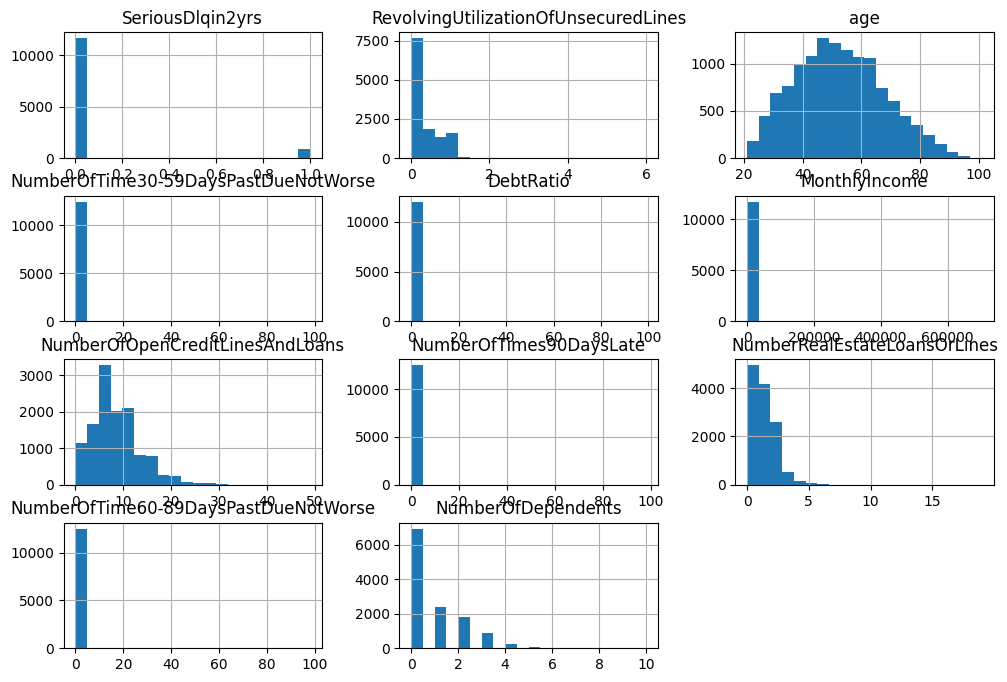

In [10]:
# Ejemplo: Histograma para todas las features numéricas
df.hist(figsize=(12,8), bins=20)

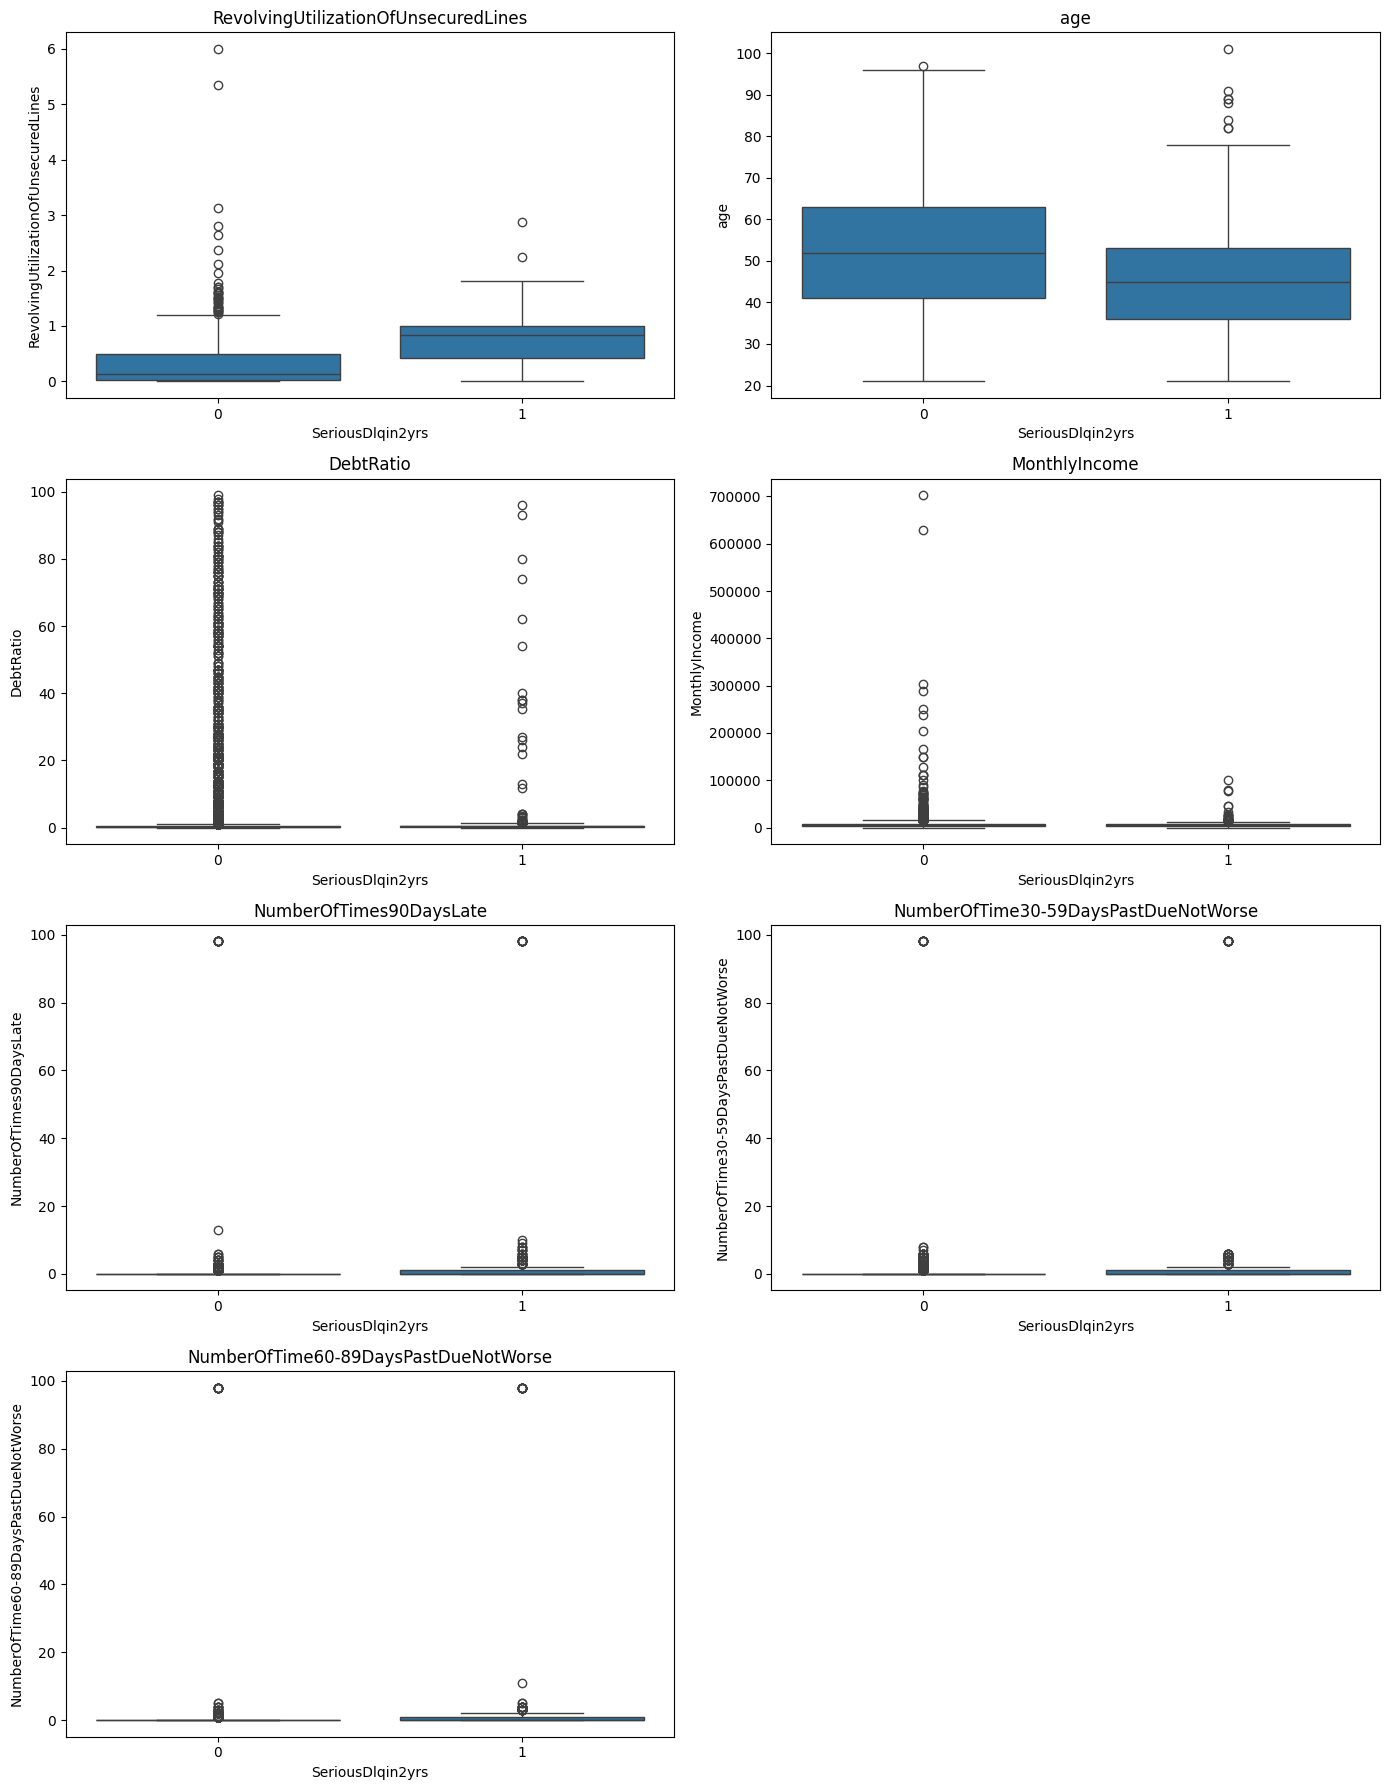

In [11]:
features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfTimes90DaysLate',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

plt.figure(figsize=(14,18))

for i, col in enumerate(features, 1):
    plt.subplot(4,2,i)
    sns.boxplot(x='SeriousDlqin2yrs', y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()


In [15]:
# Train/Test

X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [17]:
X_train

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
8818,0.952783,51,4,0.478968,15000.0,10,0,3,0,4.0
4520,1.000000,45,0,0.491605,7027.0,7,0,1,0,0.0
337,0.538922,33,0,0.089734,4100.0,3,0,0,0,0.0
12501,0.036962,46,0,0.322784,13333.0,7,0,1,0,0.0
8837,0.089869,42,1,0.091979,3652.0,3,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...
12390,0.042309,44,0,0.205981,29361.0,11,0,3,0,2.0
10382,0.227732,69,0,0.655826,3166.0,8,0,1,0,0.0
5907,0.577547,57,0,0.865273,5833.0,13,0,1,0,0.0
2165,0.926410,31,0,0.471008,1120.0,3,0,0,0,0.0


In [18]:
#Modelos con Pipeline

models = {
    'KNN': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),
    
    'RandomForest': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    
    'GradientBoosting': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', GradientBoostingClassifier(random_state=42))
    ])
}


In [19]:
# Validación cruzada

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='recall_macro'
    )
    print(f"{name} -> Recall_macro medio: {scores.mean():.4f}")


KNN -> Recall_macro medio: 0.5444
RandomForest -> Recall_macro medio: 0.5822
GradientBoosting -> Recall_macro medio: 0.5931
